# GeoATM Popularity — Baseline Models v2

**Данные:** `data/train_data_v2.csv` (6200 строк, 134 признака)  
**Модели:** LinearRegression → Ridge → Lasso → CatBoost (baseline, без тюнинга)  
**Цель:** Базовые метрики и важность признаков  
**Оптимизация:** см. `catboost_gpu_optuna.ipynb`, `xgboost_gpu_optuna.ipynb`, `LGBM.ipynb`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

RANDOM_STATE = 42
DATA_PATH = Path('../data/train_data_v2.csv')
TARGET = 'target'

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
print('OK')

OK


## 1. Загрузка данных

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nTarget stats:')
print(df[TARGET].describe())
print(f'\nMissing values (>0%), sorted:')
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(miss[miss > 0].to_string())

Shape: (6200, 134)

Target stats:
count   6200.0000
mean       0.0008
std        0.0859
min       -0.1450
25%       -0.0612
50%       -0.0155
75%        0.0402
max        0.2186
Name: target, dtype: float64

Missing values (>0%), sorted:
nearest_hypermarkets_dist_m            100.0000
nearest_money_transfer_dist_m           92.7419
nearest_railway_stations_dist_m         80.2097
nearest_payment_terminals_dist_m        77.2097
nearest_residential_buildings_dist_m    66.3226
nearest_markets_dist_m                  64.5000
nearest_highway_pedestrian_dist_m       61.8871
nearest_fuel_dist_m                     51.5323
nearest_hotels_hostels_dist_m           49.9032
nearest_fitness_sport_dist_m            44.1774
nearest_footway_100m_dist_m             40.7419
city_center_dist_m                      37.0645
nearest_residential_landuse_dist_m      32.3226
nearest_offices_dist_m                  32.2581
nearest_shops_food_small_dist_m         31.8548
nearest_landuse_mix_dist_m              31

## 2. Определение групп признаков

### Логика отбора

**Удаляем:**
- `id`, `address_raw`, `address_geocoded`, `street`, `house`, `municipality`, `country` — идентификаторы/текст
- `geo_lat`, `geo_lon` — сырые координаты, заменены на `city_center_dist_m`
- `region` — ~80 уникальных категорий, заменяем на `federal_district` + `city_size_category`
- `macro_region` — грубее `federal_district`, дублирует
- `city` — ~200 уникальных значений, слишком много
- `city_type` — дублирует `city_size_category` + бинарные `is_federal_city`
- `count_*_100m/500m/1000m` — дублируют 300m-версии (оставляем только 300m)
- `has_subway_nearby` — минимальная корреляция, дублирует `nearest_subway_dist_m`
- `population_density_per_km2` — заменяем на `population` + экономические признаки
- `nearest_hypermarkets_dist_m` — 100% пропусков
- `nearest_money_transfer_dist_m` — 93% пропусков
- `nearest_railway_stations_dist_m` — 80% пропусков
- `nearest_payment_terminals_dist_m` — 77% пропусков
- `nearest_residential_buildings_dist_m` — 66% пропусков
- `nearest_markets_dist_m` — 65% пропусков
- `nearest_highway_pedestrian_dist_m` — 62% пропусков
- `nearest_fuel_dist_m` — 52% пропусков
- `nearest_footway_100m_dist_m` — 41% пропусков, нет очевидного сигнала

In [4]:
# ─── Бинарные признаки ATM ───────────────────────────────────────────────────
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    # Географические бинарные
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
]

# ─── Дистанции до POI (log1p-преобразование) ─────────────────────────────────
# Оставляем те, у которых < 50% пропусков + есть сигнал по EDA
DISTANCE_FEATURES = [
    'nearest_malls_dist_m',                  # 23% пропусков
    'nearest_supermarkets_dist_m',           # 4%
    'nearest_pharmacies_hospitals_dist_m',   # 4%
    'nearest_cafes_dist_m',                  # 8%
    'nearest_restaurants_dist_m',            # 9%
    'nearest_public_transport_dist_m',       # 2%
    'nearest_parking_dist_m',               # 3%
    'nearest_education_dist_m',             # 25%
    'nearest_subway_dist_m',                # 25%
    'nearest_post_offices_dist_m',          # 25%
    'nearest_offices_dist_m',              # 32%, r=-0.130 СИЛЬНЫЙ сигнал
    'nearest_shops_food_small_dist_m',     # 32%
    'nearest_fitness_sport_dist_m',        # 44%
    'nearest_hotels_hostels_dist_m',       # 50%
    'land_use_dist_m',                     # 5%, r=-0.107 СИЛЬНЫЙ сигнал
    'city_center_dist_m',                  # 37%
    'nearest_residential_landuse_dist_m',  # 32%
]

# ─── Количество POI в 300м ────────────────────────────────────────────────────
COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',  # footway count (единственный radius для footway)
]

# ─── Экономические признаки ───────────────────────────────────────────────────
ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub',  # r=+0.200 — СИЛЬНЕЙШИЙ предиктор
    'grp_per_capita_2023_rub',  # r=+0.144
    'population',               # r=+0.155, 68% coverage
    'avg_income_q3_2025_rub',   # r=+0.109
]

# ─── Категориальные признаки ──────────────────────────────────────────────────
CATEGORICAL_FEATURES = [
    'federal_district',    # 8 категорий — географическая группировка
    'city_size_category',  # 4 категории: small/medium/large/million+
    'land_use_type',       # 4 категории: residential/commercial/mixed/...
    'atm_group',           # 7 значений — банк (Сбер, Альфа и т.д.)
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES

# Guard: только те колонки, которые реально есть в датасете
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Итого признаков: {len(ALL_FEATURES)}')
print(f'  Binary:    {sum(1 for f in BINARY_FEATURES if f in df.columns)}')
print(f'  Distance:  {sum(1 for f in DISTANCE_FEATURES if f in df.columns)}')
print(f'  Count 300m:{sum(1 for f in COUNT_FEATURES if f in df.columns)}')
print(f'  Economic:  {sum(1 for f in ECONOMIC_FEATURES if f in df.columns)}')
print(f'  Categ:     {sum(1 for f in CATEGORICAL_FEATURES if f in df.columns)}')

Итого признаков: 66
  Binary:    16
  Distance:  17
  Count 300m:25
  Economic:  4
  Categ:     4


## 3. Построение X, y и разбивка

In [5]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

# bool-колонки → int (иначе SimpleImputer падает)
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

# atm_group: float → str для OrdinalEncoder
X['atm_group'] = X['atm_group'].astype(str)

# Стратификация по city_size_category (заполняем NaN отдельной меткой)
strat_col = df['city_size_category'].fillna('unknown')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=strat_col,
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'Test  target: mean={y_test.mean():.4f}, std={y_test.std():.4f}')

Train: (4960, 66), Test: (1240, 66)
Train target: mean=0.0011, std=0.0856
Test  target: mean=-0.0001, std=0.0873


## 4. Препроцессинг пайплайн

In [6]:
# Фактические колонки из каждой группы (guard на случай отсутствия)
bin_cols  = [f for f in BINARY_FEATURES  if f in X.columns]
dist_cols = [f for f in DISTANCE_FEATURES if f in X.columns]
cnt_cols  = [f for f in COUNT_FEATURES   if f in X.columns]
econ_cols = [f for f in ECONOMIC_FEATURES if f in X.columns]
cat_cols  = [f for f in CATEGORICAL_FEATURES if f in X.columns]

# feature_names_out='one-to-one' нужен для get_feature_names_out в sklearn 1.8
log1p_tf = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

dist_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   log1p_tf),
    ('scaler',  StandardScaler()),
])

count_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

econ_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary',   bin_pipe,   bin_cols),
        ('distance', dist_pipe,  dist_cols),
        ('count',    count_pipe, cnt_cols),
        ('economic', econ_pipe,  econ_cols),
        ('cat',      cat_pipe,   cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

# Проверка: fit_transform на train
X_tr_transformed = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()
print(f'Transformed shape: {X_tr_transformed.shape}')
print(f'Feature names sample: {feat_names[:5]}')

Transformed shape: (4960, 66)
Feature names sample: ['binary__is_24_7' 'binary__contactless_tech' 'binary__qr_codes'
 'binary__usd_available' 'binary__eur_available']


## 5. Вспомогательные функции

In [7]:
results = []

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:40s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}


def plot_linear_importance(pipe, title, top_n=20):
    """Top-N features by |coef|, раскраска по знаку коэффициента."""
    coef = pipe.named_steps['model'].coef_
    names = pipe.named_steps['prep'].get_feature_names_out()
    clean_names = [n.split('__', 1)[-1] for n in names]

    importance = pd.Series(np.abs(coef), index=clean_names).sort_values(ascending=False)
    top = importance.head(top_n)
    sign = pd.Series(coef, index=clean_names).reindex(top.index)
    colors = ['#e74c3c' if s < 0 else '#3498db' for s in sign]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_xlabel('|Коэффициент| (в StandardScaler-единицах)')
    ax.set_title(f'{title} — Top-{top_n} признаков по |coef|')
    pos_patch = mpatches.Patch(color='#3498db', label='положительный')
    neg_patch = mpatches.Patch(color='#e74c3c', label='отрицательный')
    ax.legend(handles=[pos_patch, neg_patch])
    plt.tight_layout()
    plt.show()

    nz = np.count_nonzero(coef)
    print(f'Ненулевых коэффициентов: {nz} / {len(coef)} ({100*nz/len(coef):.1f}%)')
    return importance


def plot_cb_importance(model, feat_names, title, top_n=20):
    """CatBoost feature importance (принимает модель и список имён напрямую)."""
    clean_names = [n.split('__', 1)[-1] for n in feat_names]
    fi = model.get_feature_importance()
    importance = pd.Series(fi, index=clean_names).sort_values(ascending=False)
    top = importance.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color='#27ae60')
    ax.set_xlabel('Feature Importance (PredictionValuesChange)')
    ax.set_title(f'{title} — Top-{top_n} признаков')
    plt.tight_layout()
    plt.show()
    return importance


print('Функции определены')

Функции определены


## 6. Модель A — Linear Regression

In [8]:
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
results.append(evaluate('LinearRegression', y_test, y_pred_lr))

LinearRegression                          RMSE=0.0597  MAE=0.0475  R²=0.5320


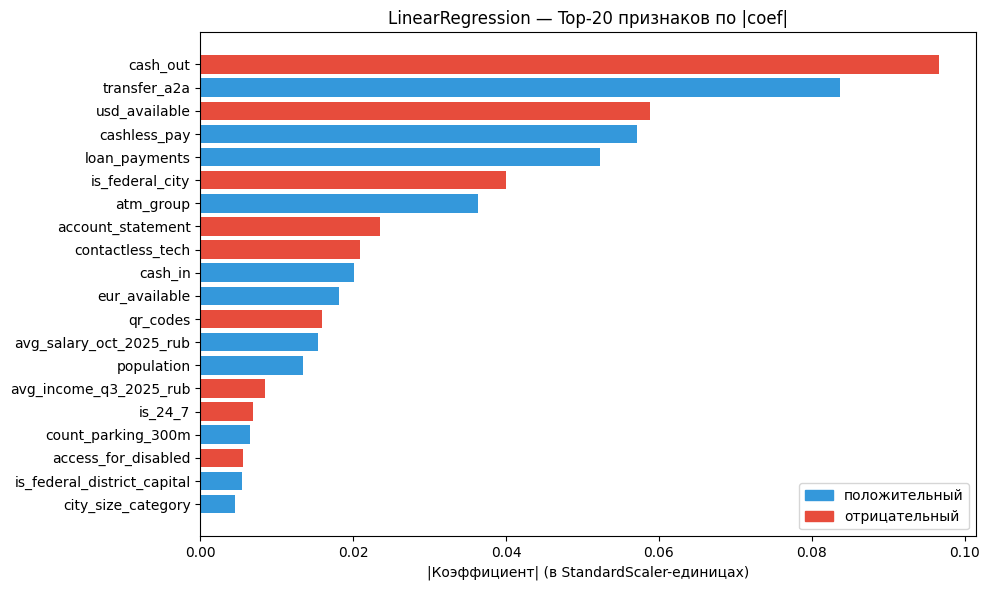

Ненулевых коэффициентов: 66 / 66 (100.0%)


In [9]:
imp_lr = plot_linear_importance(lr_pipe, 'LinearRegression')

## 7. Модель B — Ridge (alpha=1.0)

In [10]:
ridge_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge(alpha=1.0)),
])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
results.append(evaluate('Ridge (alpha=1.0)', y_test, y_pred_ridge))

Ridge (alpha=1.0)                         RMSE=0.0597  MAE=0.0475  R²=0.5319


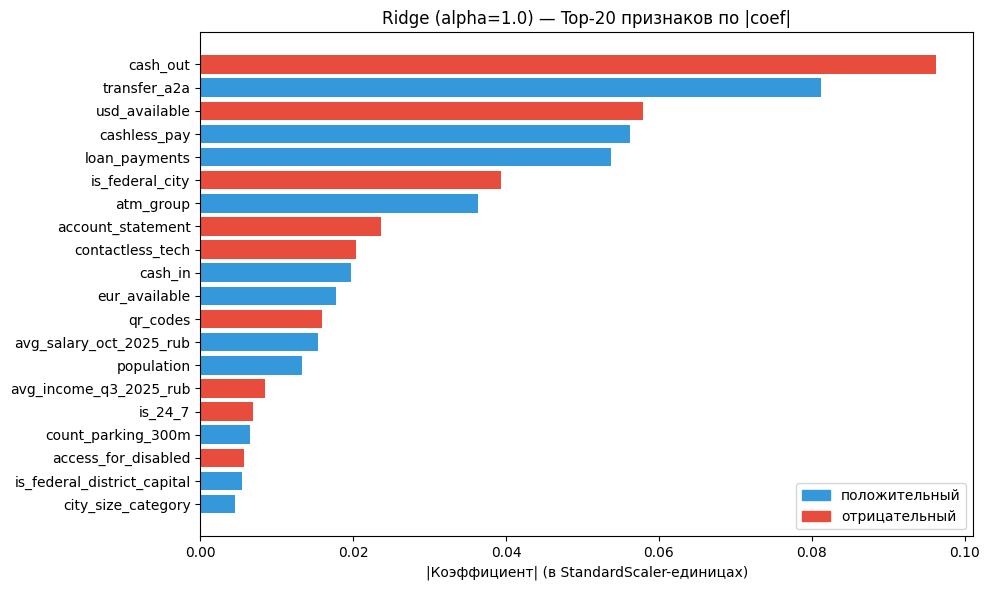

Ненулевых коэффициентов: 65 / 66 (98.5%)


In [11]:
imp_ridge = plot_linear_importance(ridge_pipe, 'Ridge (alpha=1.0)')

## 8. Модель C — Lasso (alpha=0.0001)

In [12]:
lasso_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(alpha=0.0001, max_iter=100_000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)
results.append(evaluate('Lasso (alpha=0.0001)', y_test, y_pred_lasso))

Lasso (alpha=0.0001)                      RMSE=0.0597  MAE=0.0476  R²=0.5317


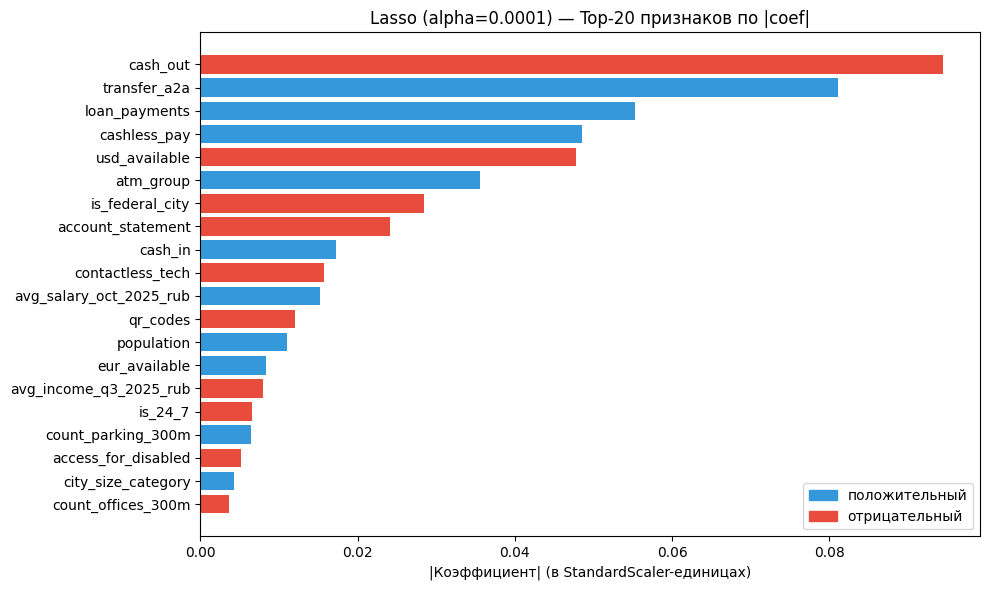

Ненулевых коэффициентов: 62 / 66 (93.9%)
Lasso обнулил: 4 из 66 признаков → осталось 62 (93.9%)


In [13]:
imp_lasso = plot_linear_importance(lasso_pipe, 'Lasso (alpha=0.0001)')
nz = np.count_nonzero(lasso_pipe.named_steps['model'].coef_)
total = len(lasso_pipe.named_steps['model'].coef_)
print(f'Lasso обнулил: {total - nz} из {total} признаков → осталось {nz} ({100*nz/total:.1f}%)')

## 9. Модель D — CatBoost (без подбора гиперпараметров)

In [14]:
# CatBoost 1.2.8 несовместим со sklearn 1.8.0 (__sklearn_tags__ отсутствует)
# Решение: используем preprocessor напрямую, CatBoost — вне Pipeline

# Препроцессор уже обучен внутри lr_pipe; используем тот же объект
cb_feat_names = preprocessor.get_feature_names_out()
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=RANDOM_STATE,
    verbose=100,
)
cb_model.fit(X_train_prep, y_train)
y_pred_cb = cb_model.predict(X_test_prep)
results.append(evaluate('CatBoost (500 iter, depth=6)', y_test, y_pred_cb))

0:	learn: 0.0829361	total: 136ms	remaining: 1m 7s
100:	learn: 0.0450432	total: 275ms	remaining: 1.09s
200:	learn: 0.0417342	total: 413ms	remaining: 614ms
300:	learn: 0.0388395	total: 555ms	remaining: 367ms
400:	learn: 0.0364190	total: 696ms	remaining: 172ms
499:	learn: 0.0342245	total: 840ms	remaining: 0us
CatBoost (500 iter, depth=6)              RMSE=0.0454  MAE=0.0366  R²=0.7290


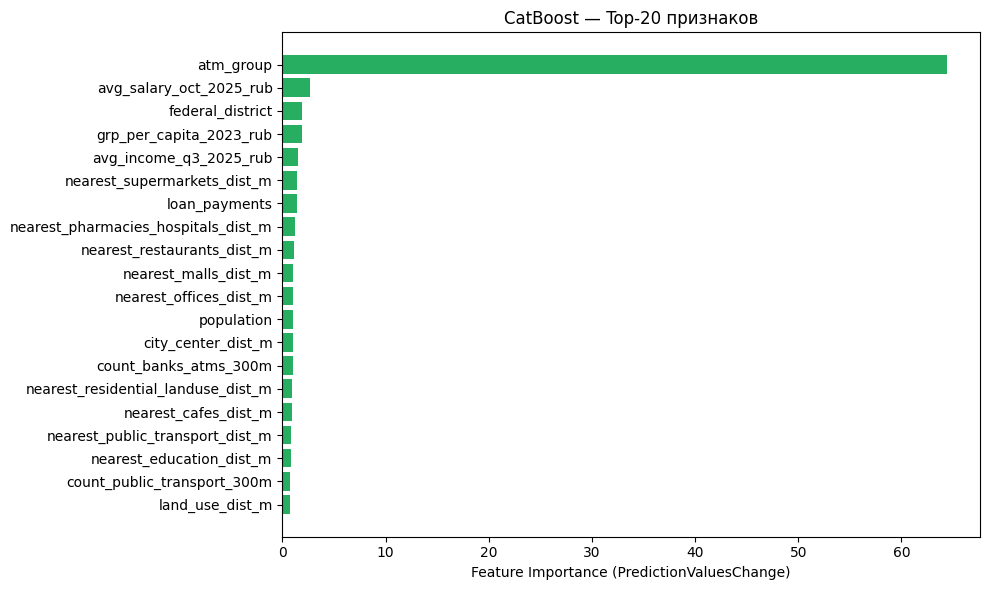

In [15]:
imp_cb = plot_cb_importance(cb_model, cb_feat_names, 'CatBoost')

## 10. Сравнительная таблица метрик

In [16]:
results_df = pd.DataFrame(results).set_index('Model')

# Прошлые baseline'ы для сравнения
baselines = pd.DataFrame([
    {'Model': '[prior] Random Forest (v1)',  'RMSE': 0.0612, 'MAE': 0.0452, 'R²': 0.5103},
    {'Model': '[prior] Lasso (v1)',           'RMSE': 0.0707, 'MAE': float('nan'), 'R²': 0.3457},
    {'Model': '[prior] Decision Tree (v1)',   'RMSE': 0.0675, 'MAE': 0.0501, 'R²': 0.4045},
]).set_index('Model')

comparison = pd.concat([results_df, baselines]).sort_values('RMSE')

display(
    comparison.style
    .highlight_min(subset=['RMSE', 'MAE'], color='#d5f5e3')
    .highlight_max(subset=['R²'], color='#d5f5e3')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'})
)

,RMSE,MAE,R²
Model,,,
"CatBoost (500 iter, depth=6)",0.0454,0.0366,0.7290
LinearRegression,0.0597,0.0475,0.5320
Ridge (alpha=1.0),0.0597,0.0475,0.5319
Lasso (alpha=0.0001),0.0597,0.0476,0.5317
[prior] Random Forest (v1),0.0612,0.0452,0.5103
[prior] Decision Tree (v1),0.0675,0.0501,0.4045
[prior] Lasso (v1),0.0707,nan,0.3457


## 11. Сравнение важностей признаков

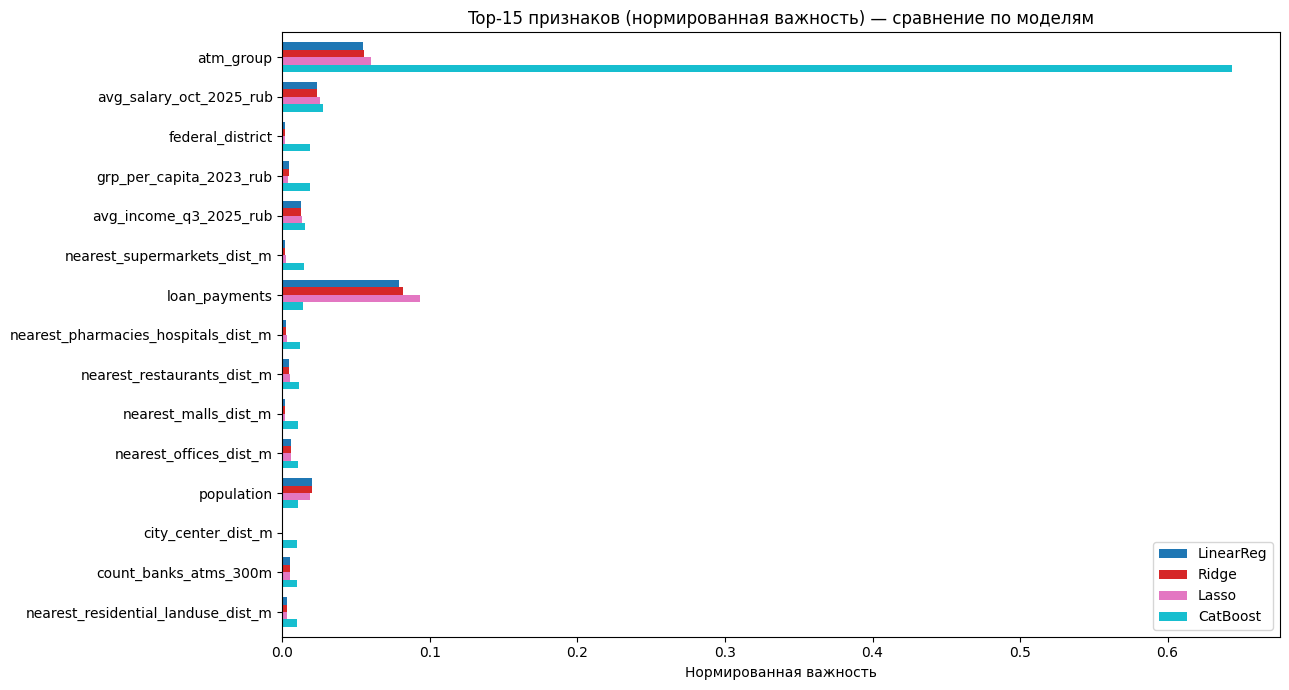

In [17]:
def get_norm_importance(pipe_or_model, feat_names=None, model_type='linear'):
    if model_type == 'linear':
        names = pipe_or_model.named_steps['prep'].get_feature_names_out()
        vals  = np.abs(pipe_or_model.named_steps['model'].coef_)
    else:
        # CatBoost вне Pipeline
        names = feat_names
        vals  = pipe_or_model.get_feature_importance()
    clean = [n.split('__', 1)[-1] for n in names]
    s = pd.Series(vals, index=clean)
    return s / s.sum()

imp_lr_n    = get_norm_importance(lr_pipe,    model_type='linear')
imp_ridge_n = get_norm_importance(ridge_pipe, model_type='linear')
imp_lasso_n = get_norm_importance(lasso_pipe, model_type='linear')
imp_cb_n    = get_norm_importance(cb_model, feat_names=cb_feat_names, model_type='catboost')

# Top-15 по CatBoost (наиболее надёжный)
top15 = imp_cb_n.sort_values(ascending=False).head(15).index

imp_compare = pd.DataFrame({
    'LinearReg':  imp_lr_n.reindex(top15),
    'Ridge':      imp_ridge_n.reindex(top15),
    'Lasso':      imp_lasso_n.reindex(top15),
    'CatBoost':   imp_cb_n.reindex(top15),
}).fillna(0)

fig, ax = plt.subplots(figsize=(13, 7))
imp_compare.plot(kind='barh', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Top-15 признаков (нормированная важность) — сравнение по моделям')
ax.set_xlabel('Нормированная важность')
ax.invert_yaxis()
plt.tight_layout()
plt.show()